<a href="https://colab.research.google.com/github/JeaLPaHu/telecomx-challenge-part2/blob/main/telecomx_challenge_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 TelecomX LATAM — Parte 2: Predicción de Cancelación (Churn)

Este notebook continúa el trabajo realizado en la Parte 1.  
A partir de los datos originales aplicamos el mismo pipeline ETL y luego construimos
modelos de Machine Learning para **predecir qué clientes tienen mayor probabilidad de cancelar**.

### 🗺️ Estructura del notebook
1. **Extracción y limpieza** — mismo pipeline de la Parte 1
2. **Preparación para ML** — encoding, balanceo, normalización
3. **Modelado** — Regresión Logística + Random Forest
4. **Evaluación** — métricas y matriz de confusión
5. **Interpretación** — importancia de variables
6. **Conclusión estratégica**

## 📥 1. Extracción y Limpieza de Datos

Cargamos el dataset original desde GitHub y aplicamos
el mismo pipeline ETL de la Parte 1 para obtener
el dataset limpio, traducido y listo para el modelado.

## 🛠️ 2. Preparación de los Datos

Transformamos el dataset limpio de la Parte 1 para dejarlo listo para los algoritmos de Machine Learning:

1. Eliminación de columnas irrelevantes
2. Encoding de variables categóricas
3. Verificación del desbalance de clases
4. Balanceo con SMOTE
5. Normalización con StandardScaler

In [2]:
# Extracción del archivo tratado desde la Parte 1
# Cargamos el dataset directamente desde la URL del JSON original
# y aplicamos el mismo pipeline ETL de la Parte 1 para obtener
# el dataset limpio, traducido y listo para el modelado

import requests
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

# Limpieza
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df = df[df['Churn'].str.strip() != '']
df = df.dropna(subset=['account.Charges.Total'])

# Renombrado al español
columnas = {
    'customerID': 'id', 'Churn': 'cancelacion',
    'customer.gender': 'genero', 'customer.SeniorCitizen': 'tiene_mas_60',
    'customer.Partner': 'posee_pareja', 'customer.Dependents': 'posee_dependientes',
    'customer.tenure': 'tiempo_contrato', 'phone.PhoneService': 'servicio_telefonico',
    'phone.MultipleLines': 'multiples_lineas', 'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguridad_online', 'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'proteccion_dispositivo', 'internet.TechSupport': 'soporte_tecnico',
    'internet.StreamingTV': 'streaming_tv', 'internet.StreamingMovies': 'streaming_peliculas',
    'account.Contract': 'tipo_contrato', 'account.PaperlessBilling': 'factura_digital',
    'account.PaymentMethod': 'metodo_pago', 'account.Charges.Monthly': 'cargo_mensual',
    'account.Charges.Total': 'cargo_total',
}
df = df.rename(columns=columnas)

# Traducción de valores
df['cancelacion']         = df['cancelacion'].replace({'Yes': 'Sí', 'No': 'No'})
df['genero']              = df['genero'].replace({'Female': 'Femenino', 'Male': 'Masculino'})
df['posee_pareja']        = df['posee_pareja'].replace({'Yes': 'Sí', 'No': 'No'})
df['posee_dependientes']  = df['posee_dependientes'].replace({'Yes': 'Sí', 'No': 'No'})
df['factura_digital']     = df['factura_digital'].replace({'Yes': 'Sí', 'No': 'No'})
df['servicio_telefonico'] = df['servicio_telefonico'].replace({'Yes': 'Sí', 'No': 'No'})

mapeo = {'Yes': 'Sí', 'No': 'No',
         'No internet service': 'Sin servicio de internet',
         'No phone service': 'Sin servicio telefónico'}
for col in ['seguridad_online','backup_online','proteccion_dispositivo',
            'soporte_tecnico','streaming_tv','streaming_peliculas','multiples_lineas']:
    df[col] = df[col].replace(mapeo)

df['metodo_pago'] = df['metodo_pago'].replace({
    'Mailed check': 'Cheque por correo',
    'Electronic check': 'Cheque electrónico',
    'Credit card (automatic)': 'Tarjeta de crédito (automático)',
    'Bank transfer (automatic)': 'Transferencia bancaria (automática)'
})

df['cuentas_diarias'] = (df['cargo_mensual'] / 30).round(2)

print(f"✅ Dataset listo: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

✅ Dataset listo: 7,032 filas × 22 columnas


,id,cancelacion,genero,tiene_mas_60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefonico,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total,cuentas_diarias
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,...,No,Sí,Sí,No,One year,Sí,Cheque por correo,65.6,593.30,2.19
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,...,No,No,No,Sí,Month-to-month,No,Cheque por correo,59.9,542.40,2.00
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,...,Sí,No,No,No,Month-to-month,Sí,Cheque electrónico,73.9,280.85,2.46
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fiber optic,...,Sí,No,Sí,Sí,Month-to-month,Sí,Cheque electrónico,98.0,1237.85,3.27
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fiber optic,...,No,Sí,Sí,No,Month-to-month,Sí,Cheque por correo,83.9,267.40,2.80


In [4]:
# Eliminamos columnas que no aportan valor predictivo al modelo
# 'id': identificador único del cliente, no tiene patrón estadístico explotable
# 'cuentas_diarias': derivada directa de cargo_mensual (cargo/30), información redundante

df_ml = df.drop(columns=['id', 'cuentas_diarias'])
print(f"Columnas eliminadas : id, cuentas_diarias")
print(f"Columnas restantes  : {df_ml.shape[1]}")
print(df_ml.columns.tolist())

Columnas eliminadas : id, cuentas_diarias
Columnas restantes  : 20
['cancelacion', 'genero', 'tiene_mas_60', 'posee_pareja', 'posee_dependientes', 'tiempo_contrato', 'servicio_telefonico', 'multiples_lineas', 'tipo_internet', 'seguridad_online', 'backup_online', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas', 'tipo_contrato', 'factura_digital', 'metodo_pago', 'cargo_mensual', 'cargo_total']


In [5]:
# Separamos la variable objetivo antes del encoding
# para evitar que 'cancelacion' también sea codificada

y_raw = df_ml['cancelacion']
X_raw = df_ml.drop(columns=['cancelacion'])

# One-Hot Encoding sobre todas las columnas categóricas (dtype object)
# drop_first=True elimina una columna por variable para evitar multicolinealidad
# (ej: si 'genero_Femenino' = 0 entonces es Masculino, no necesitamos ambas)

X_encoded = pd.get_dummies(X_raw, drop_first=True)

# Convertimos la variable objetivo a binario: 1 = canceló, 0 = no canceló
y = (y_raw == 'Sí').astype(int)

print(f"Variables predictoras tras encoding : {X_encoded.shape[1]}")
print(f"Distribución de la variable objetivo:")
print(y.value_counts().rename({0: 'No canceló (0)', 1: 'Canceló (1)'}))

Variables predictoras tras encoding : 30
Distribución de la variable objetivo:
cancelacion
No canceló (0)    5163
Canceló (1)       1869
Name: count, dtype: int64


Total clientes    : 7,032
Cancelaron (1)    : 1,869  (26.6%)
No cancelaron (0) : 5,163  (73.4%)


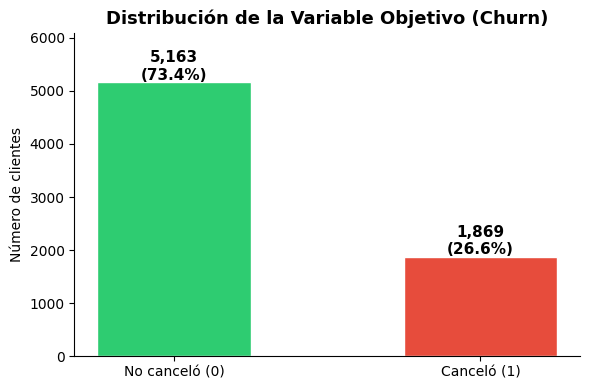

In [6]:
# Calculamos la proporción de clientes que cancelaron vs. los que permanecieron
# Si la clase minoritaria (canceló) es < 30% del total, el desbalance es relevante
# y puede hacer que el modelo aprenda a predecir casi siempre la clase mayoritaria

total      = len(y)
n_churn    = y.sum()
n_no_churn = total - n_churn
pct_churn  = n_churn / total * 100

print(f"Total clientes    : {total:,}")
print(f"Cancelaron (1)    : {n_churn:,}  ({pct_churn:.1f}%)")
print(f"No cancelaron (0) : {n_no_churn:,}  ({100 - pct_churn:.1f}%)")

# Visualización del desbalance
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No canceló (0)', 'Canceló (1)'], [n_no_churn, n_churn],
              color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
for bar, val in zip(bars, [n_no_churn, n_churn]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({val/total*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Distribución de la Variable Objetivo (Churn)', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de clientes')
ax.set_ylim(0, n_no_churn * 1.18)
sns.despine()
plt.tight_layout()
plt.show()

In [7]:
# SMOTE (Synthetic Minority Oversampling Technique) genera ejemplos sintéticos
# de la clase minoritaria interpolando entre vecinos cercanos en el espacio de features
# Esto balancea el dataset sin simplemente repetir datos existentes

# IMPORTANTE: aplicamos SMOTE SOLO sobre el conjunto de entrenamiento
# para no contaminar la evaluación con datos sintéticos
# Si aplicáramos SMOTE antes del split, el modelo "vería" datos del test indirectamente

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_raw, y_train_raw)

print(f"Train original   → {y_train_raw.value_counts().to_dict()}")
print(f"Train balanceado → {pd.Series(y_train_bal).value_counts().to_dict()}")
print(f"Test (sin tocar) → {y_test.value_counts().to_dict()}")

Train original   → {0: 4130, 1: 1495}
Train balanceado → {0: 4130, 1: 4130}
Test (sin tocar) → {0: 1033, 1: 374}


In [8]:
# Estandarizamos las variables numéricas a media=0 y desviación estándar=1
# Esto es OBLIGATORIO para la Regresión Logística ya que la optimización
# de gradiente es sensible a la escala: features grandes dominarían el ajuste
# El Random Forest NO lo necesita (basado en particiones, no en distancias)

# IMPORTANTE: ajustamos el scaler SOLO con datos de entrenamiento (fit_transform)
# y lo aplicamos al test sin reajustar (transform)
# Si ajustáramos con el test, el modelo "vería" información del futuro → data leakage

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

print("✅ Normalización aplicada correctamente")
print(f"   Media  de la primera feature en train : {X_train_scaled[:,0].mean():.4f}")
print(f"   Std    de la primera feature en train : {X_train_scaled[:,0].std():.4f}")
print(f"\n   Shape train : {X_train_scaled.shape}")
print(f"   Shape test  : {X_test_scaled.shape}")

✅ Normalización aplicada correctamente
   Media  de la primera feature en train : -0.0000
   Std    de la primera feature en train : 1.0000

   Shape train : (8260, 30)
   Shape test  : (1407, 30)


## 📊 3. Contexto Visual — Análisis Exploratorio (EDA)

Antes de preparar los datos para ML, repasamos los principales hallazgos
visuales del análisis exploratorio de la Parte 1. Esto nos permite:

- Entender la distribución de la variable objetivo
- Identificar los factores de riesgo visualmente
- Justificar las decisiones de modelado que tomaremos después

In [21]:
# Importamos os para manejo de carpetas y google.colab para descarga de archivos
# Creamos la carpeta images/ donde se guardarán todos los gráficos
# Esta función centraliza el guardado y descarga de cada imagen generada

import os
from google.colab import files

os.makedirs('images', exist_ok=True)

def guardar_grafico(nombre_archivo):
    ruta = f'images/{nombre_archivo}'
    plt.savefig(ruta, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    files.download(ruta)
    print(f'✅ Descargado: {nombre_archivo}')

print("✅ Carpeta images/ lista")

✅ Carpeta images/ lista


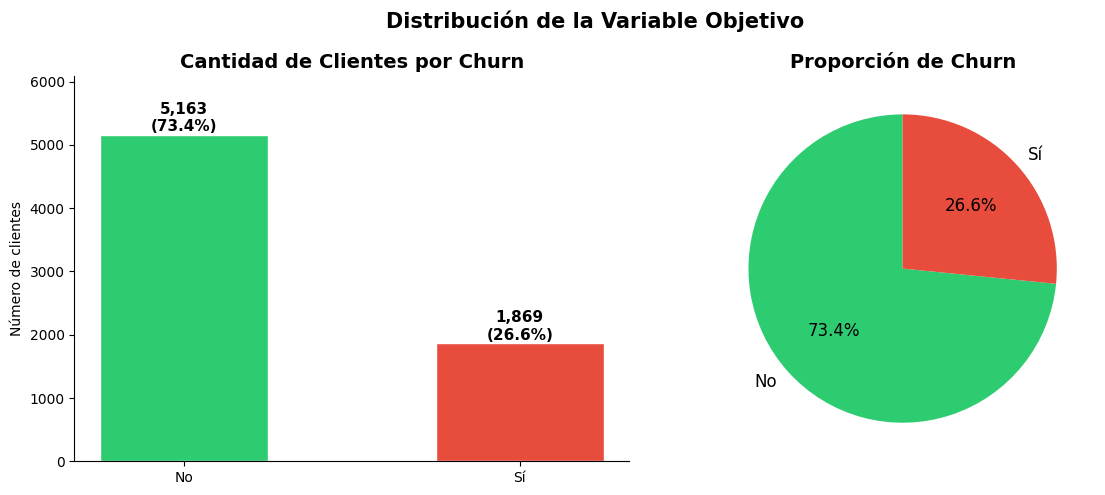

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargado: 01_distribucion_churn.png


In [22]:
# Distribución de la variable objetivo: cuántos clientes cancelaron vs. permanecieron
# Este es el punto de partida del análisis — conocer el desbalance real del negocio

COLORS = {'No': '#2ecc71', 'Sí': '#e74c3c'}

churn_counts = df['cancelacion'].value_counts()
churn_pct    = df['cancelacion'].value_counts(normalize=True).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico izquierdo: conteo absoluto
axes[0].bar(churn_counts.index, churn_counts.values,
            color=[COLORS['No'], COLORS['Sí']], edgecolor='white', width=0.5)
for i, (val, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, val + 50, f'{val:,}\n({pct}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Cantidad de Clientes por Churn', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Número de clientes')
axes[0].set_ylim(0, churn_counts.max() * 1.18)
sns.despine(ax=axes[0])

# Gráfico derecho: proporción en torta
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            colors=[COLORS['No'], COLORS['Sí']],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Proporción de Churn', fontsize=14, fontweight='bold')

plt.suptitle('Distribución de la Variable Objetivo', fontsize=15, fontweight='bold')
plt.tight_layout()
guardar_grafico('01_distribucion_churn.png')

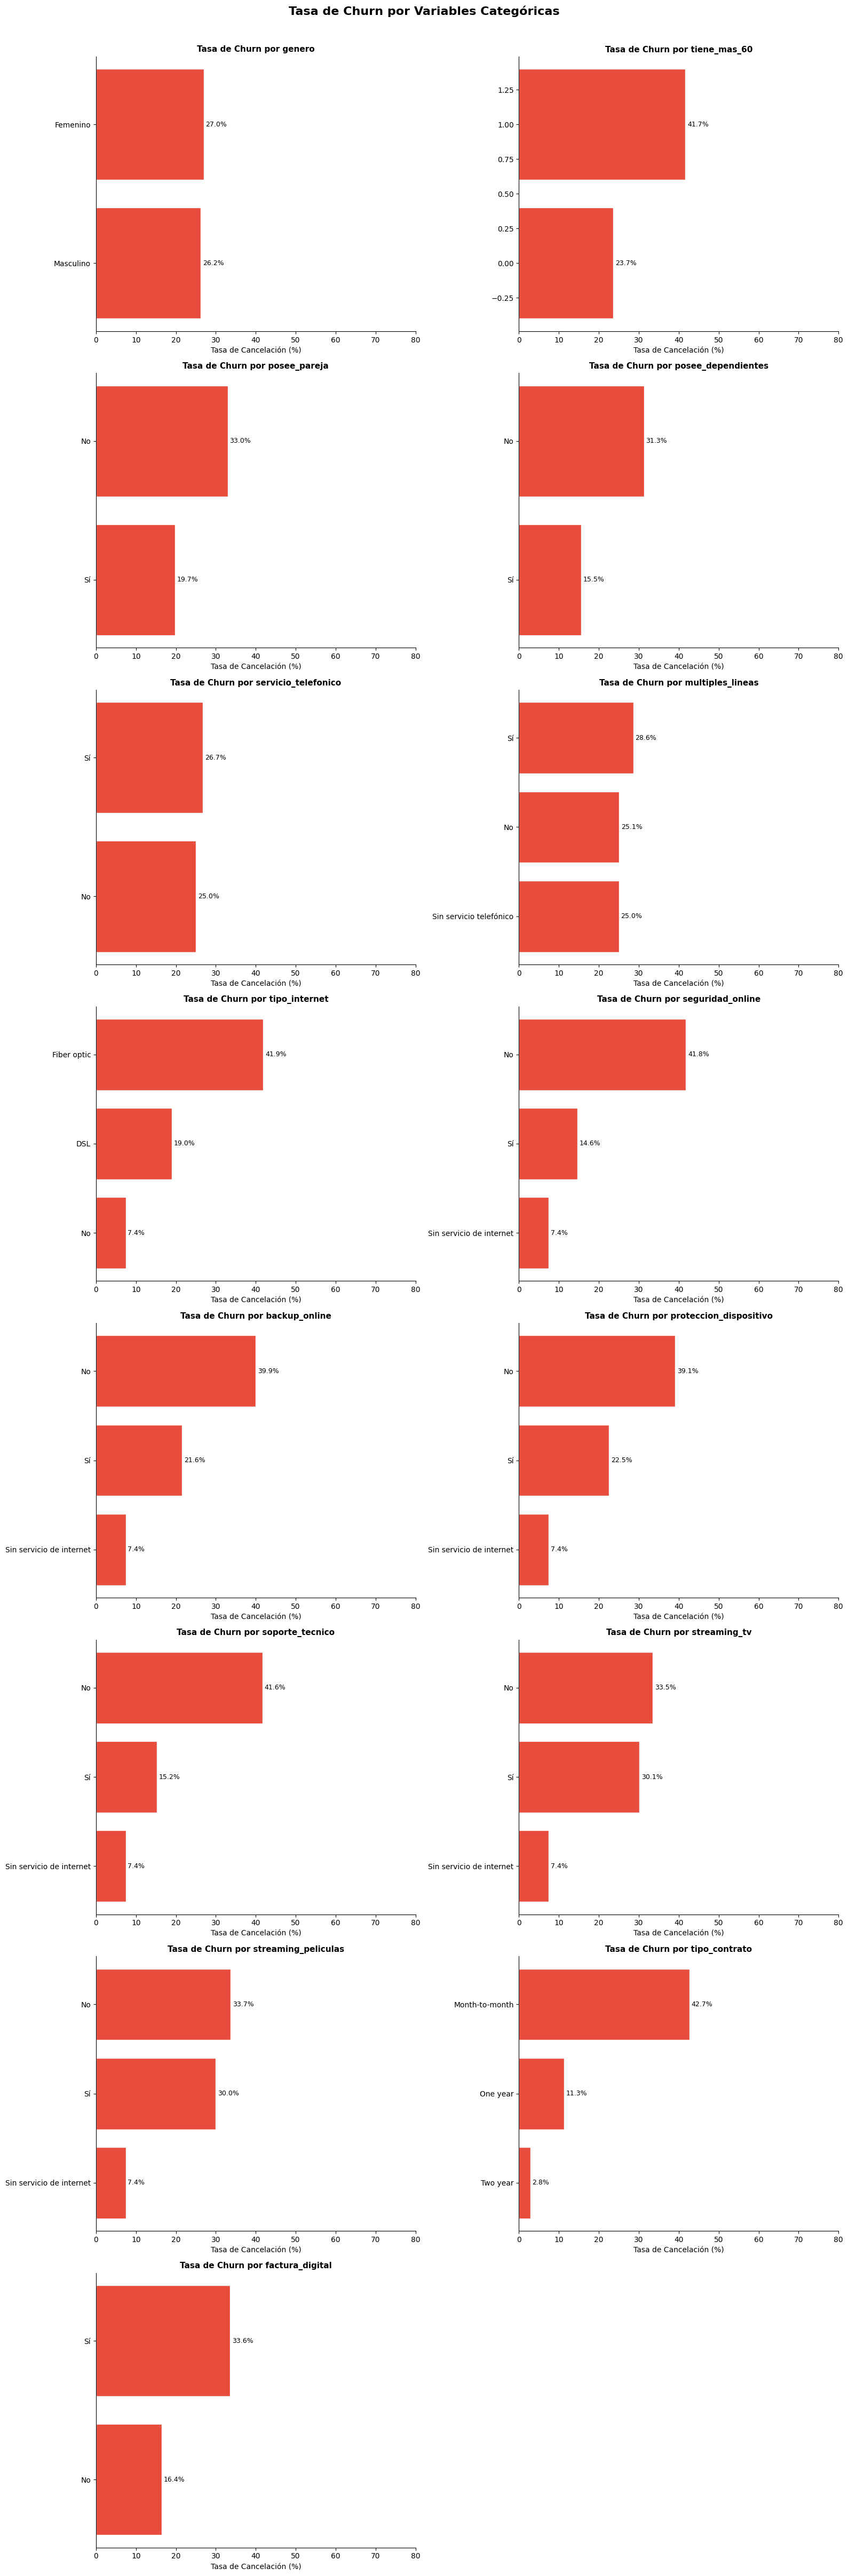

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargado: 02_churn_variables_categoricas.png


In [23]:
# Tasa de cancelación por cada categoría de las variables más relevantes
# Ordenamos de mayor a menor para identificar las categorías de mayor riesgo
# Cada barra representa el % de clientes que cancelaron en esa categoría

cat_vars = [
    'genero', 'tiene_mas_60', 'posee_pareja', 'posee_dependientes',
    'servicio_telefonico', 'multiples_lineas', 'tipo_internet',
    'seguridad_online', 'backup_online', 'proteccion_dispositivo',
    'soporte_tecnico', 'streaming_tv', 'streaming_peliculas',
    'tipo_contrato', 'factura_digital', 'metodo_pago'
]

fig, axes = plt.subplots(8, 2, figsize=(16, 48))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    tasa = (df.groupby(col)['cancelacion']
              .apply(lambda x: (x == 'Sí').mean() * 100)
              .reset_index()
              .rename(columns={'cancelacion': 'tasa_churn'})
              .sort_values('tasa_churn', ascending=True))
    bars = axes[i].barh(tasa[col], tasa['tasa_churn'],
                        color='#e74c3c', edgecolor='white')
    for bar, val in zip(bars, tasa['tasa_churn']):
        axes[i].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)
    axes[i].set_title(f'Tasa de Churn por {col}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Tasa de Cancelación (%)')
    axes[i].set_xlim(0, 80)
    sns.despine(ax=axes[i])

axes[-1].set_visible(False)
plt.suptitle('Tasa de Churn por Variables Categóricas', fontsize=16, fontweight='bold', y=1.005)
plt.tight_layout()
guardar_grafico('02_churn_variables_categoricas.png')

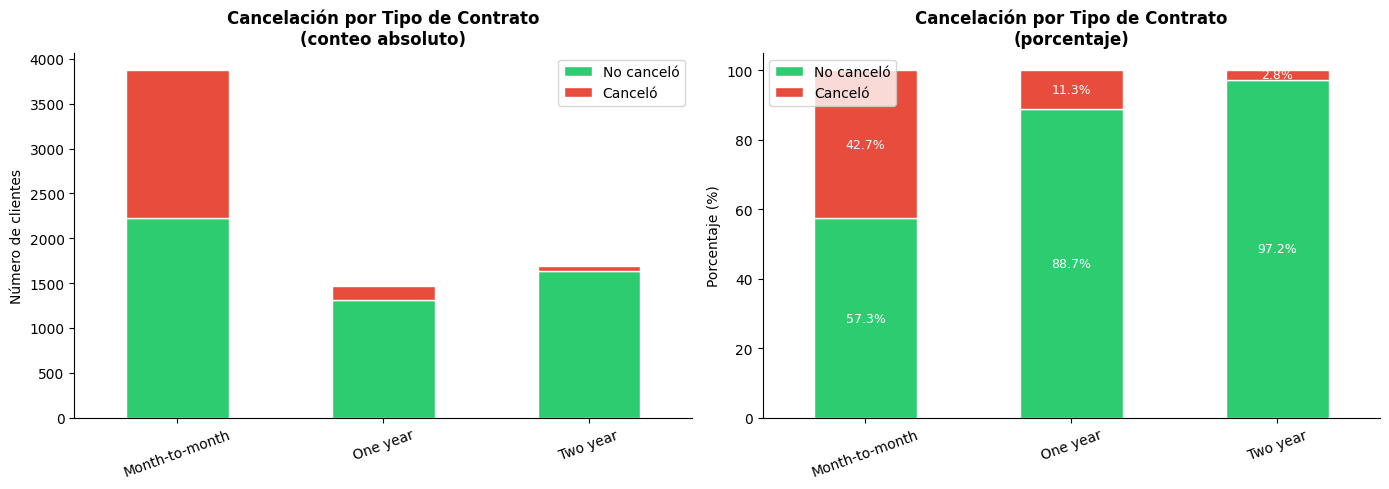

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargado: 03_churn_tipo_contrato.png


In [24]:
# Tasa de cancelación por tipo de contrato — el factor más crítico identificado
# Mostramos conteo absoluto y porcentual lado a lado
# para entender tanto el volumen como la tasa de riesgo por segmento

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico izquierdo: conteo absoluto apilado
ct_abs = pd.crosstab(df['tipo_contrato'], df['cancelacion'])
ct_abs.plot(kind='bar', stacked=True, ax=axes[0],
            color=[COLORS['No'], COLORS['Sí']], edgecolor='white')
axes[0].set_title('Cancelación por Tipo de Contrato\n(conteo absoluto)',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Número de clientes')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(['No canceló', 'Canceló'])
sns.despine(ax=axes[0])

# Gráfico derecho: porcentaje apilado
ct_pct = pd.crosstab(df['tipo_contrato'], df['cancelacion'], normalize='index').mul(100)
ct_pct.plot(kind='bar', stacked=True, ax=axes[1],
            color=[COLORS['No'], COLORS['Sí']], edgecolor='white')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9, color='white')
axes[1].set_title('Cancelación por Tipo de Contrato\n(porcentaje)',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(['No canceló', 'Canceló'])
sns.despine(ax=axes[1])

plt.tight_layout()
guardar_grafico('03_churn_tipo_contrato.png')

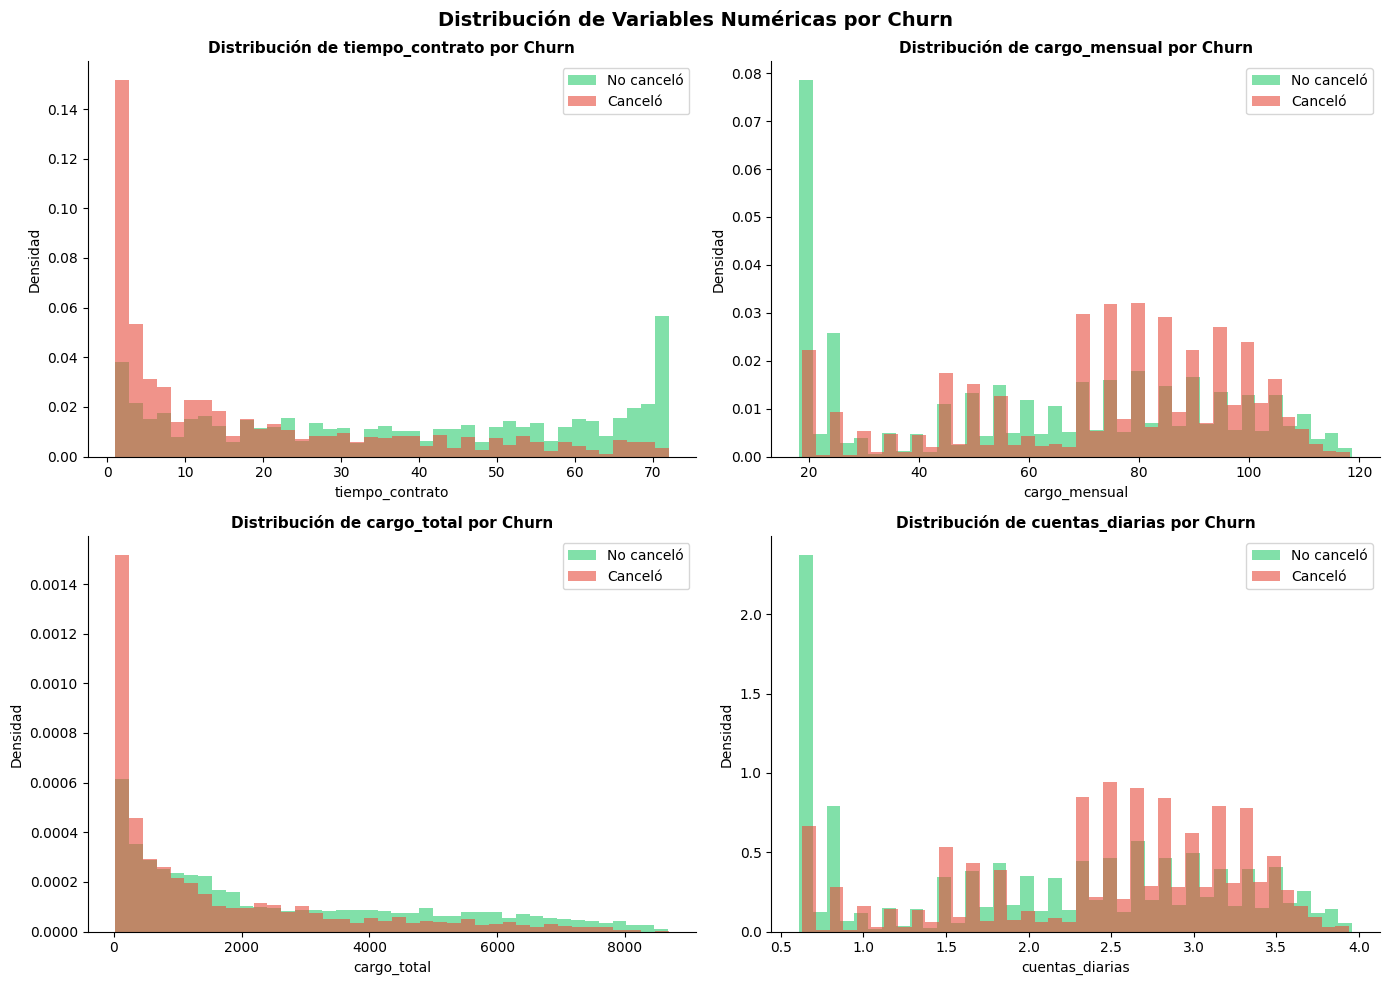

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargado: 04_distribucion_numericas_churn.png


In [25]:
# Distribución de variables numéricas separada por grupo de cancelación
# Si las curvas se separan claramente, la variable es un buen predictor de churn
# density=True normaliza los histogramas para comparar grupos de distinto tamaño

num_vars = ['tiempo_contrato', 'cargo_mensual', 'cargo_total', 'cuentas_diarias']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    for label, color in [('No', '#2ecc71'), ('Sí', '#e74c3c')]:
        subset = df[df['cancelacion'] == label][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color,
                     label=f'{"No canceló" if label == "No" else "Canceló"}',
                     edgecolor='none', density=True)
    axes[i].set_title(f'Distribución de {col} por Churn', fontweight='bold', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densidad')
    axes[i].legend()
    sns.despine(ax=axes[i])

plt.suptitle('Distribución de Variables Numéricas por Churn',
             fontsize=14, fontweight='bold')
plt.tight_layout()
guardar_grafico('04_distribucion_numericas_churn.png')

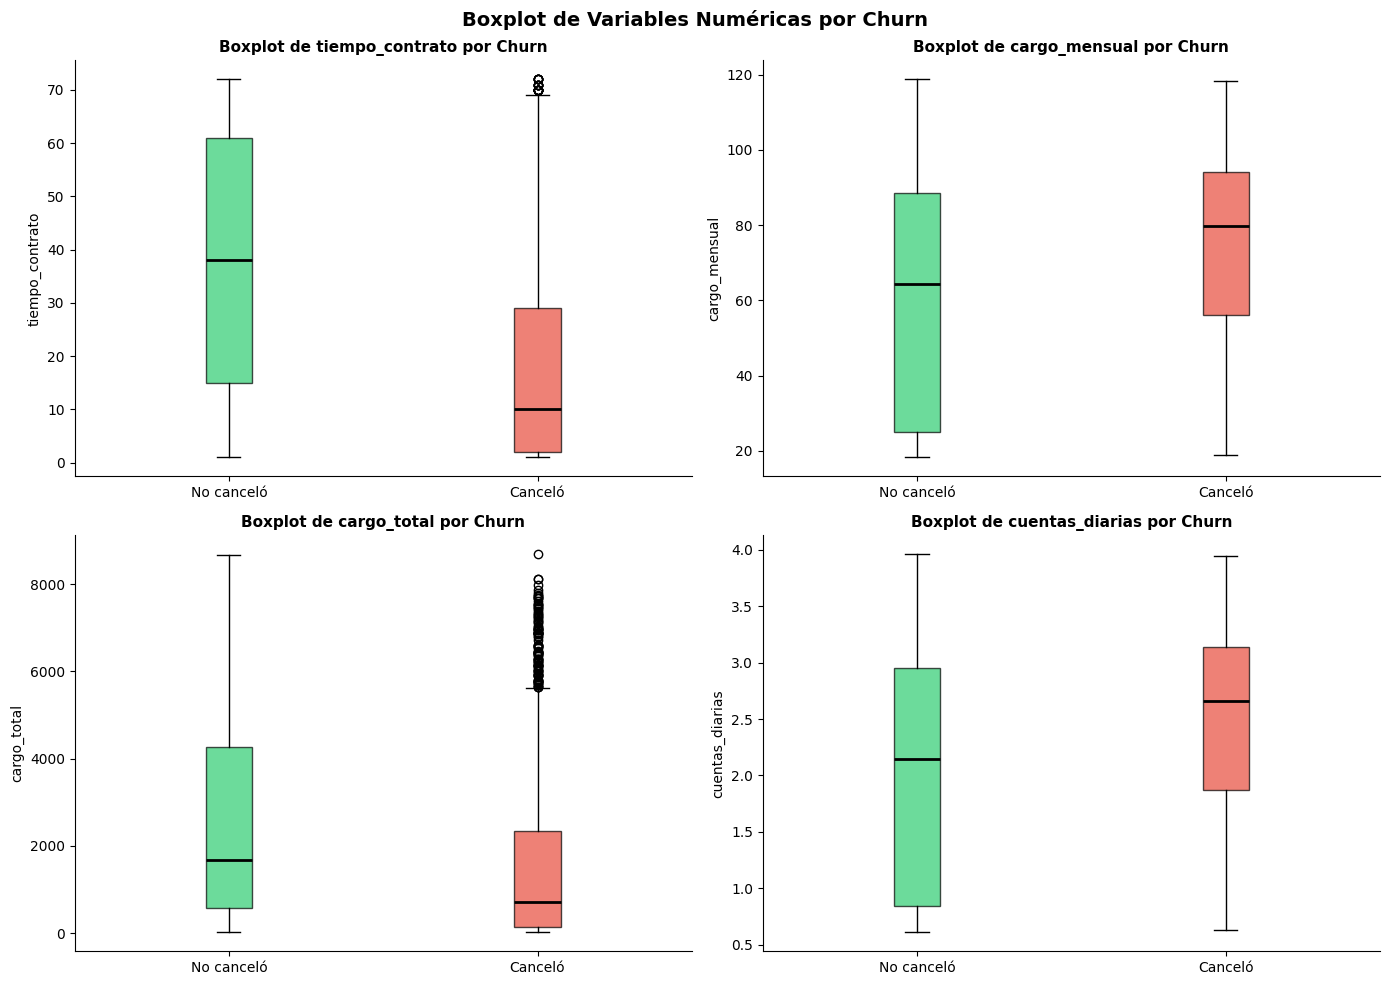

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargado: 05_boxplot_numericas_churn.png


In [26]:
# Boxplots de variables numéricas por grupo de cancelación
# Muestran mediana, cuartiles y outliers de forma compacta
# Útiles para confirmar si las diferencias entre grupos son significativas

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    data_plot = [
        df[df['cancelacion'] == 'No'][col].dropna(),
        df[df['cancelacion'] == 'Sí'][col].dropna()
    ]
    bp = axes[i].boxplot(data_plot, patch_artist=True,
                          labels=['No canceló', 'Canceló'],
                          medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for patch in bp['boxes']:
        patch.set_alpha(0.7)
    axes[i].set_title(f'Boxplot de {col} por Churn', fontweight='bold', fontsize=11)
    axes[i].set_ylabel(col)
    sns.despine(ax=axes[i])

plt.suptitle('Boxplot de Variables Numéricas por Churn',
             fontsize=14, fontweight='bold')
plt.tight_layout()
guardar_grafico('05_boxplot_numericas_churn.png')

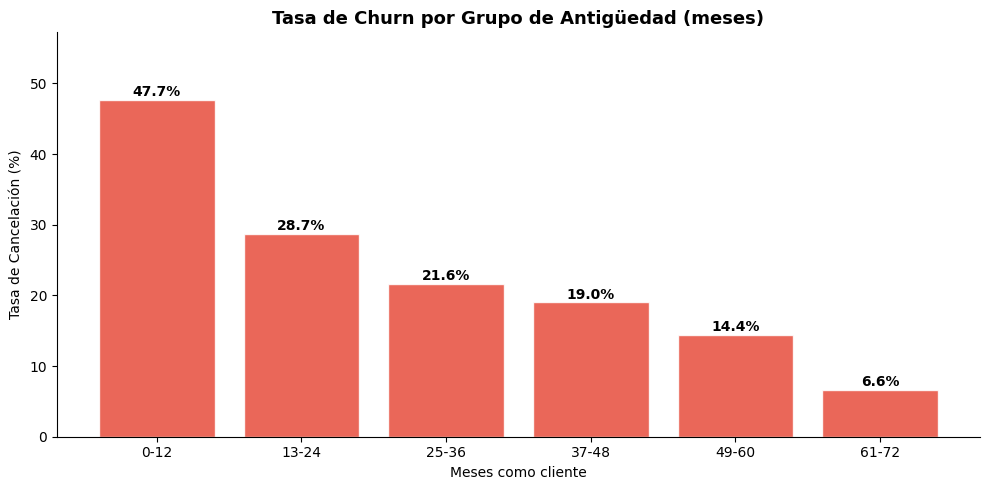

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargado: 06_churn_grupo_antiguedad.png


In [27]:
# Segmentamos la antigüedad en rangos de 12 meses para ver la evolución del churn
# Permite identificar en qué etapa de la relación el riesgo de cancelación es mayor
# El primer año es generalmente el período más crítico de retención

bins   = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
df['grupo_antiguedad'] = pd.cut(df['tiempo_contrato'], bins=bins,
                                 labels=labels, include_lowest=True)

tasa_ant = (df.groupby('grupo_antiguedad', observed=True)['cancelacion']
              .apply(lambda x: (x == 'Sí').mean() * 100)
              .reset_index()
              .rename(columns={'cancelacion': 'tasa_churn'}))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(tasa_ant['grupo_antiguedad'], tasa_ant['tasa_churn'],
              color='#e74c3c', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, tasa_ant['tasa_churn']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Tasa de Churn por Grupo de Antigüedad (meses)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Meses como cliente')
ax.set_ylabel('Tasa de Cancelación (%)')
ax.set_ylim(0, tasa_ant['tasa_churn'].max() * 1.2)
sns.despine()
plt.tight_layout()
guardar_grafico('06_churn_grupo_antiguedad.png')

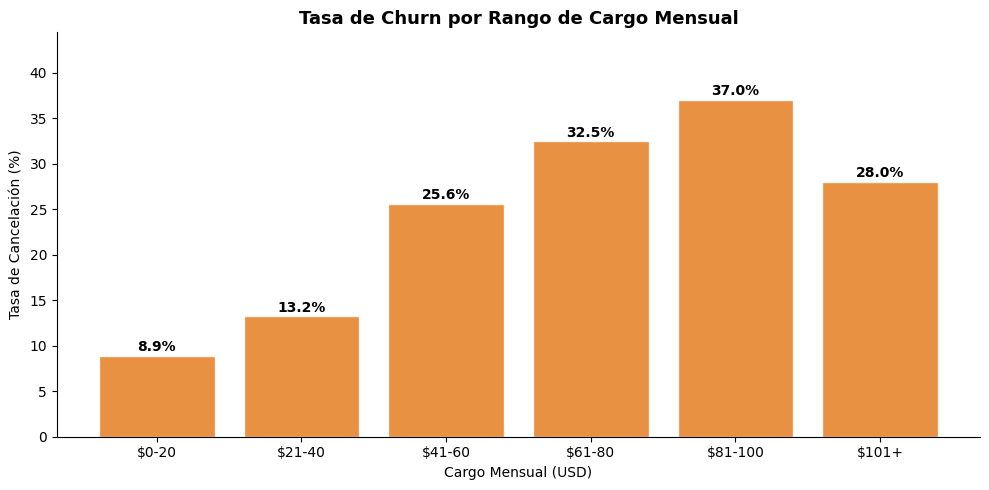

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargado: 07_churn_cargo_mensual.png


In [28]:
# Segmentamos el cargo mensual en rangos de $20 para analizar sensibilidad al precio
# Si la tasa de churn aumenta con el precio, el valor percibido no justifica el costo
# Clave para diseñar estrategias de pricing y retención

bins_m   = [0, 20, 40, 60, 80, 100, 120]
labels_m = ['$0-20', '$21-40', '$41-60', '$61-80', '$81-100', '$101+']
df['rango_cargo_mensual'] = pd.cut(df['cargo_mensual'], bins=bins_m,
                                    labels=labels_m, include_lowest=True)

tasa_cm = (df.groupby('rango_cargo_mensual', observed=True)['cancelacion']
             .apply(lambda x: (x == 'Sí').mean() * 100)
             .reset_index()
             .rename(columns={'cancelacion': 'tasa_churn'}))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(tasa_cm['rango_cargo_mensual'], tasa_cm['tasa_churn'],
              color='#e67e22', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, tasa_cm['tasa_churn']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Tasa de Churn por Rango de Cargo Mensual',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cargo Mensual (USD)')
ax.set_ylabel('Tasa de Cancelación (%)')
ax.set_ylim(0, tasa_cm['tasa_churn'].max() * 1.2)
sns.despine()
plt.tight_layout()
guardar_grafico('07_churn_cargo_mensual.png')

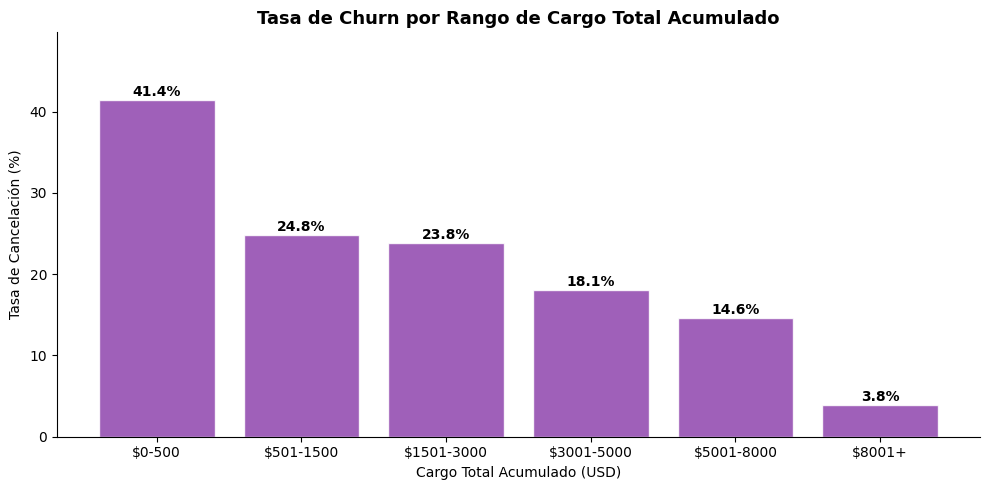

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargado: 08_churn_cargo_total.png


In [29]:
# El cargo total acumulado refleja el valor histórico del cliente
# Clientes con bajo cargo total son nuevos o de bajo consumo — más propensos a irse
# Esta segmentación ayuda a identificar el perfil financiero de los que cancelan

bins_t   = [0, 500, 1500, 3000, 5000, 8000, 10000]
labels_t = ['$0-500', '$501-1500', '$1501-3000', '$3001-5000', '$5001-8000', '$8001+']
df['rango_cargo_total'] = pd.cut(df['cargo_total'], bins=bins_t,
                                  labels=labels_t, include_lowest=True)

tasa_ct = (df.groupby('rango_cargo_total', observed=True)['cancelacion']
             .apply(lambda x: (x == 'Sí').mean() * 100)
             .reset_index()
             .rename(columns={'cancelacion': 'tasa_churn'}))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(tasa_ct['rango_cargo_total'], tasa_ct['tasa_churn'],
              color='#8e44ad', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, tasa_ct['tasa_churn']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Tasa de Churn por Rango de Cargo Total Acumulado',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cargo Total Acumulado (USD)')
ax.set_ylabel('Tasa de Cancelación (%)')
ax.set_ylim(0, tasa_ct['tasa_churn'].max() * 1.2)
sns.despine()
plt.tight_layout()
guardar_grafico('08_churn_cargo_total.png')

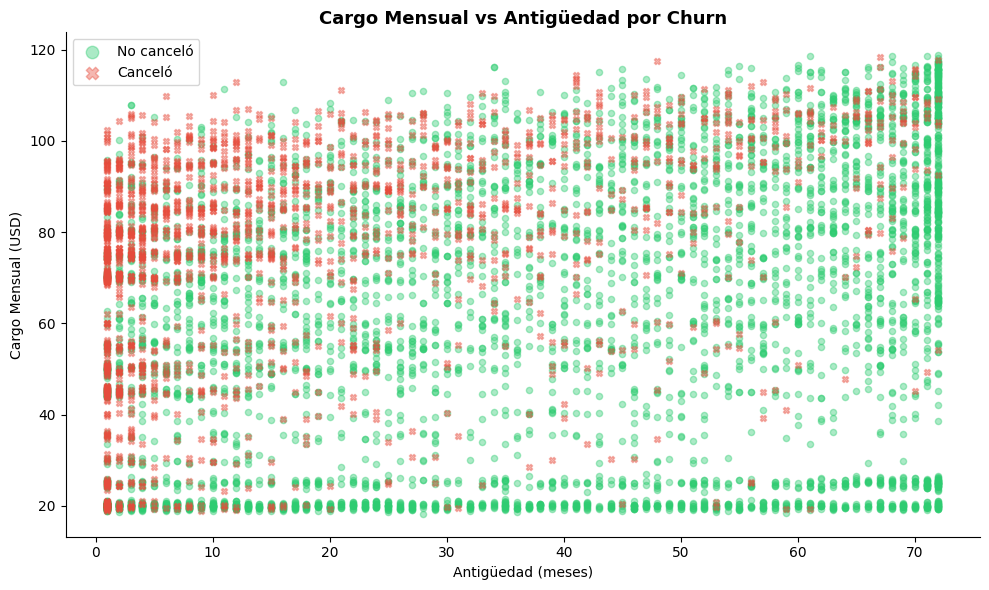

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargado: 09_scatter_cargo_antiguedad.png


In [30]:
# Scatter plot: relación entre precio y antigüedad diferenciando por cancelación
# Buscamos si los clientes que cancelan se concentran en alguna zona específica
# Zona de mayor riesgo esperada: cargo alto + poca antigüedad (esquina superior izquierda)

fig, ax = plt.subplots(figsize=(10, 6))

for label, color, marker in [('No', '#2ecc71', 'o'), ('Sí', '#e74c3c', 'X')]:
    subset = df[df['cancelacion'] == label]
    ax.scatter(subset['tiempo_contrato'], subset['cargo_mensual'],
               c=color, label=f'{"No canceló" if label == "No" else "Canceló"}',
               alpha=0.4, s=20, marker=marker)

ax.set_title('Cargo Mensual vs Antigüedad por Churn',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Antigüedad (meses)')
ax.set_ylabel('Cargo Mensual (USD)')
ax.legend(markerscale=2)
sns.despine()
plt.tight_layout()
guardar_grafico('09_scatter_cargo_antiguedad.png')

## 🎯 4. Correlación y Selección de Variables

Antes de entrenar los modelos analizamos qué variables tienen mayor relación
con la cancelación. Esto nos permite:

- Entender qué factores impulsan el churn
- Confirmar que el encoding fue correcto
- Tener una hipótesis antes de ver los resultados del modelo

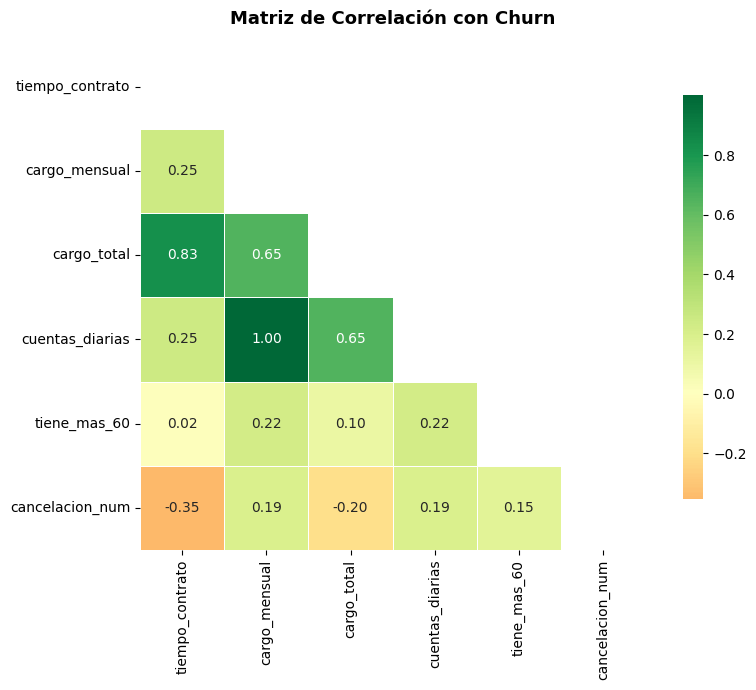

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargado: 10_matriz_correlacion.png

=== CORRELACIÓN CON CHURN ===
tiempo_contrato   -0.354
cargo_total       -0.199
cuentas_diarias    0.193
cargo_mensual      0.193
tiene_mas_60       0.151
Name: cancelacion_num, dtype: float64


In [31]:
# La matriz de correlación muestra la relación lineal entre variables numéricas
# La fila 'cancelacion_num' indica qué variables se relacionan más con el churn
# -0.35 en tiempo_contrato → a mayor antigüedad, menos probabilidad de cancelar
#  0.19 en cargo_mensual  → a mayor cargo, más probabilidad de cancelar

df['cancelacion_num'] = (df['cancelacion'] == 'Sí').astype(int)

num_df = df[['tiempo_contrato', 'cargo_mensual', 'cargo_total',
             'cuentas_diarias', 'tiene_mas_60', 'cancelacion_num']]

corr = num_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Matriz de Correlación con Churn',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
guardar_grafico('10_matriz_correlacion.png')

print("\n=== CORRELACIÓN CON CHURN ===")
print(corr['cancelacion_num'].drop('cancelacion_num')
      .sort_values(key=abs, ascending=False).round(3))

In [10]:
# Análisis dirigido: profundizamos en las variables con mayor correlación con el churn
# Calculamos la tasa de cancelación agrupada por las variables categóricas más relevantes
# Esto complementa la matriz de correlación con una visión más clara por segmento

print("=== TASA DE CANCELACIÓN POR VARIABLES CLAVE ===\n")

variables_clave = [
    'tipo_contrato', 'tipo_internet', 'metodo_pago',
    'seguridad_online', 'soporte_tecnico', 'factura_digital'
]

for col in variables_clave:
    tasa = (df_ml.groupby(col)['cancelacion']
               .apply(lambda x: (x == 'Sí').mean() * 100)
               .sort_values(ascending=False)
               .round(1))
    print(f"── {col} ──")
    print(tasa.to_string())
    print()

# Variables numéricas: comparación de medias entre grupos
print("=== MEDIA DE VARIABLES NUMÉRICAS POR GRUPO ===\n")
print(df_ml.groupby('cancelacion')[['tiempo_contrato', 'cargo_mensual', 'cargo_total']]
      .mean().round(2))

=== TASA DE CANCELACIÓN POR VARIABLES CLAVE ===

── tipo_contrato ──
tipo_contrato
Month-to-month    42.7
One year          11.3
Two year           2.8

── tipo_internet ──
tipo_internet
Fiber optic    41.9
DSL            19.0
No              7.4

── metodo_pago ──
metodo_pago
Cheque electrónico                     45.3
Cheque por correo                      19.2
Transferencia bancaria (automática)    16.7
Tarjeta de crédito (automático)        15.3

── seguridad_online ──
seguridad_online
No                          41.8
Sí                          14.6
Sin servicio de internet     7.4

── soporte_tecnico ──
soporte_tecnico
No                          41.6
Sí                          15.2
Sin servicio de internet     7.4

── factura_digital ──
factura_digital
Sí    33.6
No    16.4

=== MEDIA DE VARIABLES NUMÉRICAS POR GRUPO ===

             tiempo_contrato  cargo_mensual  cargo_total
cancelacion                                             
No                     37.65          61.31 

## 🤖 5. Modelado Predictivo

Entrenamos dos modelos con enfoques distintos para predecir la cancelación:

| Modelo | Normalización | Ventaja |
|---|---|---|
| **Regresión Logística** | ✅ Requiere | Interpretable, coeficientes directos |
| **Random Forest** | ❌ No requiere | Mayor precisión, captura no linealidades |

La división del dataset es **80% entrenamiento / 20% prueba** con `stratify=y`
para mantener la misma proporción de churn en ambos conjuntos.

In [11]:
# Dividimos el dataset en entrenamiento y prueba
# test_size=0.2: 80% para entrenar, 20% para evaluar
# random_state=42: garantiza reproducibilidad — siempre el mismo split
# stratify=y: mantiene la misma proporción de churn en ambos conjuntos
# sin stratify, por azar podría quedar más churn en train que en test

from sklearn.model_selection import train_test_split

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train_raw.shape[0]:,} filas ({X_train_raw.shape[0]/len(X_encoded)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,} filas ({X_test.shape[0]/len(X_encoded)*100:.0f}%)")
print(f"\nProporción de churn en train : {y_train_raw.mean()*100:.1f}%")
print(f"Proporción de churn en test  : {y_test.mean()*100:.1f}%")

Train : 5,625 filas (80%)
Test  : 1,407 filas (20%)

Proporción de churn en train : 26.6%
Proporción de churn en test  : 26.6%


In [12]:
# ── Modelo 1: Regresión Logística ────────────────────────────────────────
# Usa los datos NORMALIZADOS porque la optimización de gradiente
# es sensible a la escala: features grandes dominarían el ajuste
# max_iter=1000 asegura convergencia en datasets con muchas variables

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_bal)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("✅ Regresión Logística entrenada")

✅ Regresión Logística entrenada


In [13]:
# ── Modelo 2: Random Forest ──────────────────────────────────────────────
# Usa los datos SIN normalizar porque las particiones de los árboles
# son invariantes a la escala: solo comparan umbrales relativos
# n_estimators=200: número de árboles, más árboles = más estabilidad
# class_weight='balanced': peso adicional a la clase minoritaria

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("✅ Random Forest entrenado")

✅ Random Forest entrenado


## 📋 6. Evaluación de los Modelos

Usamos múltiples métricas porque la exactitud (accuracy) sola engaña en datasets desbalanceados:

| Métrica | Qué mide |
|---|---|
| **Precision** | De los predichos como cancelación, ¿cuántos realmente cancelaron? |
| **Recall** | De los que realmente cancelaron, ¿cuántos detectamos? |
| **F1-Score** | Media armónica entre Precision y Recall |
| **ROC-AUC** | Capacidad discriminativa global del modelo (1 = perfecto) |

In [14]:
# Función auxiliar para imprimir métricas de forma uniforme
# classification_report incluye precision, recall, f1 y support por clase
# ROC-AUC mide la capacidad discriminativa global del modelo

from sklearn.metrics import classification_report, roc_auc_score

def evaluar_modelo(nombre, y_true, y_pred, y_prob):
    print(f"{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred,
                                 target_names=['No canceló', 'Canceló']))
    auc = roc_auc_score(y_true, y_prob)
    print(f"  ROC-AUC: {auc:.4f}")
    print()

evaluar_modelo("REGRESIÓN LOGÍSTICA", y_test, y_pred_lr, y_prob_lr)
evaluar_modelo("RANDOM FOREST",       y_test, y_pred_rf, y_prob_rf)

  REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

  No canceló       0.87      0.84      0.85      1033
     Canceló       0.59      0.65      0.62       374

    accuracy                           0.79      1407
   macro avg       0.73      0.74      0.74      1407
weighted avg       0.80      0.79      0.79      1407

  ROC-AUC: 0.8343

  RANDOM FOREST
              precision    recall  f1-score   support

  No canceló       0.85      0.84      0.85      1033
     Canceló       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407

  ROC-AUC: 0.8236



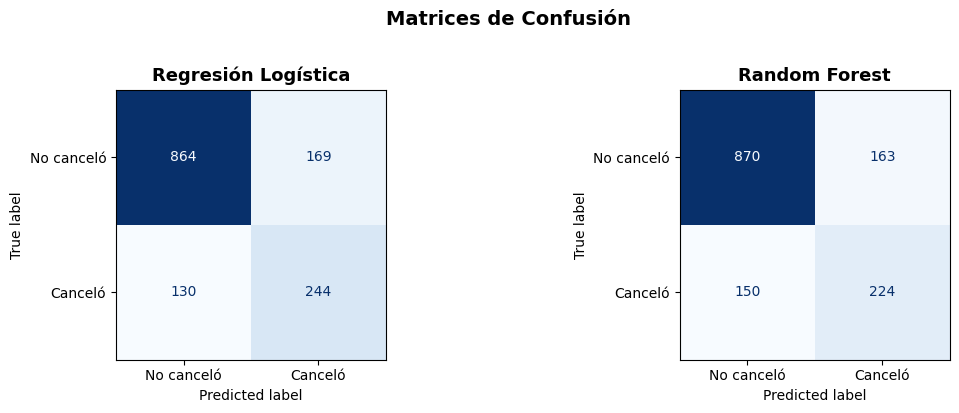

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargado: 11_matrices_confusion.png


In [32]:
# Matrices de Confusión lado a lado para comparar ambos modelos
# TN (izq-sup): predijo No y era No ✅
# FP (der-sup): predijo Sí pero era No ❌
# FN (izq-inf): predijo No pero era Sí ❌ ← los más costosos, clientes que perdemos
# TP (der-inf): predijo Sí y era Sí ✅

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, titulo in zip(
        axes,
        [y_pred_lr, y_pred_rf],
        ['Regresión Logística', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No canceló', 'Canceló'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontsize=13, fontweight='bold')

plt.suptitle('Matrices de Confusión', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
guardar_grafico('11_matrices_confusion.png')

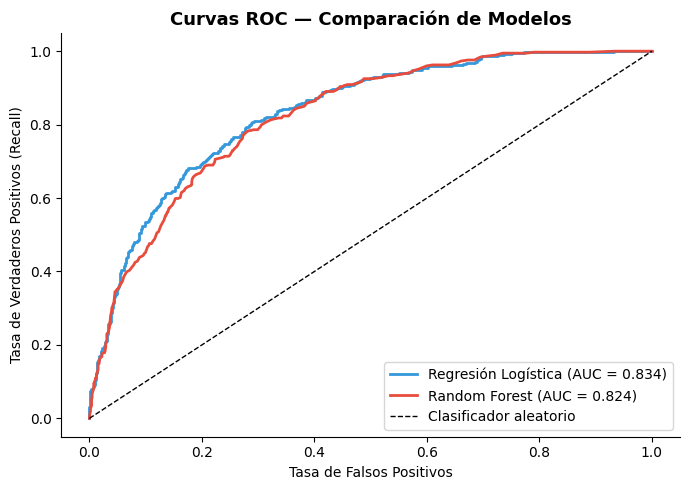

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargado: 12_curvas_roc.png


In [33]:
# Curvas ROC — comparan ambos modelos en un mismo gráfico
# Un modelo perfecto tiene AUC = 1.0
# Un modelo aleatorio tiene AUC = 0.5 (línea punteada)
# Cuanto más arriba y a la izquierda la curva, mejor el modelo

from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(7, 5))
for y_prob, label, color in [
        (y_prob_lr, 'Regresión Logística', '#3498db'),
        (y_prob_rf, 'Random Forest',       '#e74c3c')]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {auc:.3f})', color=color, lw=2)

ax.plot([0,1],[0,1], 'k--', lw=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax.set_title('Curvas ROC — Comparación de Modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
guardar_grafico('12_curvas_roc.png')

## 🔍 7. Interpretación y Conclusiones

Analizamos qué variables influyen más en la predicción de cancelación
según cada modelo:

- **Regresión Logística** → coeficientes: valor positivo = aumenta el riesgo de cancelar
- **Random Forest** → importancia Gini: qué tanto contribuye cada variable a las decisiones del bosque

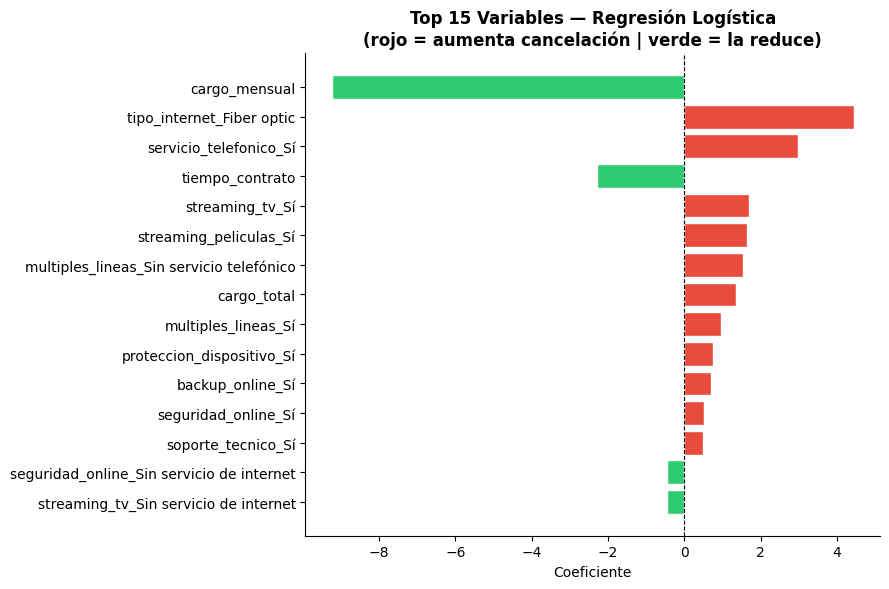

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargado: 13_top15_regresion_logistica.png


In [34]:
# Los coeficientes de la Regresión Logística son interpretables directamente
# Un coeficiente positivo significa que esa variable AUMENTA la probabilidad de cancelar
# Visualizamos los 15 más importantes (mayores en valor absoluto)

coef_df = pd.DataFrame({
    'variable':    X_encoded.columns,
    'coeficiente': log_reg.coef_[0]
}).sort_values('coeficiente', key=abs, ascending=False).head(15)

colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['coeficiente']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_df['variable'], coef_df['coeficiente'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top 15 Variables — Regresión Logística\n(rojo = aumenta cancelación | verde = la reduce)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coeficiente')
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
guardar_grafico('13_top15_regresion_logistica.png')

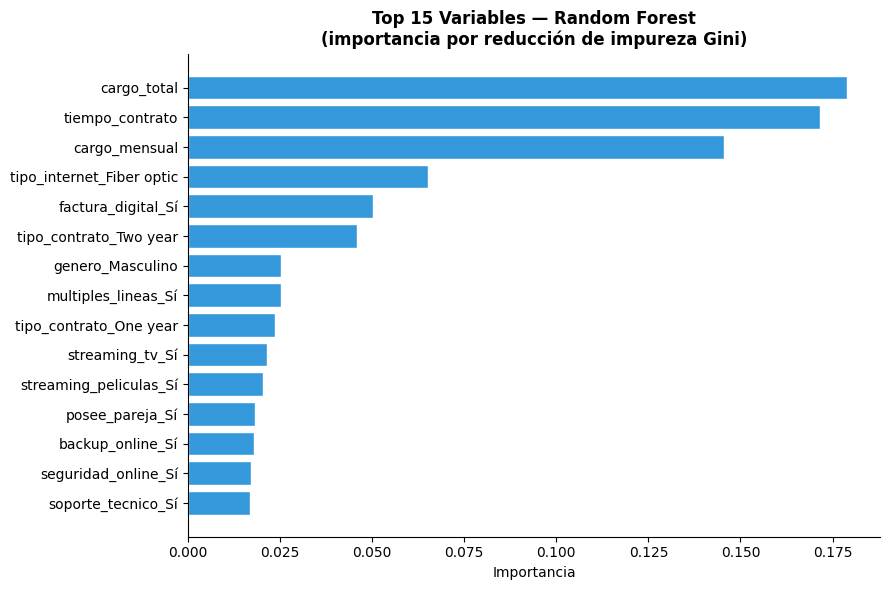

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargado: 14_top15_random_forest.png


In [35]:
# La importancia de cada variable se mide por su contribución promedio
# a reducir la impureza de Gini en todos los árboles del bosque
# Variables con alta importancia son las más útiles para discriminar cancelación

imp_df = pd.DataFrame({
    'variable':    X_encoded.columns,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df['variable'], imp_df['importancia'], color='#3498db', edgecolor='white')
ax.set_title('Top 15 Variables — Random Forest\n(importancia por reducción de impureza Gini)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia')
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
guardar_grafico('14_top15_random_forest.png')

In [19]:
# Comparamos los top 10 de cada modelo para ver qué variables coinciden
# La coincidencia entre modelos distintos aumenta la confianza en esas variables
# Son los factores de riesgo más sólidos para la toma de decisiones

top_lr = set(coef_df['variable'].head(10))
top_rf = set(imp_df['variable'].head(10))
comunes = top_lr & top_rf

print("Variables en top 10 de AMBOS modelos (mayor confianza):")
for v in sorted(comunes):
    print(f"  ✅ {v}")

print(f"\nSolo en Regresión Logística : {top_lr - comunes}")
print(f"Solo en Random Forest       : {top_rf - comunes}")

Variables en top 10 de AMBOS modelos (mayor confianza):
  ✅ cargo_mensual
  ✅ cargo_total
  ✅ multiples_lineas_Sí
  ✅ streaming_tv_Sí
  ✅ tiempo_contrato
  ✅ tipo_internet_Fiber optic

Solo en Regresión Logística : {'proteccion_dispositivo_Sí', 'servicio_telefonico_Sí', 'streaming_peliculas_Sí', 'multiples_lineas_Sin servicio telefónico'}
Solo en Random Forest       : {'tipo_contrato_One year', 'genero_Masculino', 'factura_digital_Sí', 'tipo_contrato_Two year'}


In [20]:
# Analizamos en detalle las variables más importantes identificadas por ambos modelos
# Calculamos la tasa de cancelación real por categoría para validar
# que lo que el modelo aprendió coincide con los patrones reales del negocio

print("=== VALIDACIÓN DE VARIABLES IMPORTANTES ===\n")

# Tipo de contrato — top variable en ambos modelos
print("── Tasa de churn por tipo_contrato ──")
print(df_ml.groupby('tipo_contrato')['cancelacion']
      .apply(lambda x: (x == 'Sí').mean() * 100).round(1).sort_values(ascending=False))

# Tiempo de contrato — antigüedad del cliente
print("\n── Promedio de tiempo_contrato por grupo ──")
print(df_ml.groupby('cancelacion')['tiempo_contrato'].mean().round(1))

# Cargo mensual — sensibilidad al precio
print("\n── Promedio de cargo_mensual por grupo ──")
print(df_ml.groupby('cancelacion')['cargo_mensual'].mean().round(2))

# Tipo de internet
print("\n── Tasa de churn por tipo_internet ──")
print(df_ml.groupby('tipo_internet')['cancelacion']
      .apply(lambda x: (x == 'Sí').mean() * 100).round(1).sort_values(ascending=False))

# Método de pago
print("\n── Tasa de churn por metodo_pago ──")
print(df_ml.groupby('metodo_pago')['cancelacion']
      .apply(lambda x: (x == 'Sí').mean() * 100).round(1).sort_values(ascending=False))

# Servicios adicionales
print("\n── Tasa de churn por soporte_tecnico ──")
print(df_ml.groupby('soporte_tecnico')['cancelacion']
      .apply(lambda x: (x == 'Sí').mean() * 100).round(1).sort_values(ascending=False))

print("\n── Tasa de churn por seguridad_online ──")
print(df_ml.groupby('seguridad_online')['cancelacion']
      .apply(lambda x: (x == 'Sí').mean() * 100).round(1).sort_values(ascending=False))

=== VALIDACIÓN DE VARIABLES IMPORTANTES ===

── Tasa de churn por tipo_contrato ──
tipo_contrato
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: cancelacion, dtype: float64

── Promedio de tiempo_contrato por grupo ──
cancelacion
No    37.7
Sí    18.0
Name: tiempo_contrato, dtype: float64

── Promedio de cargo_mensual por grupo ──
cancelacion
No    61.31
Sí    74.44
Name: cargo_mensual, dtype: float64

── Tasa de churn por tipo_internet ──
tipo_internet
Fiber optic    41.9
DSL            19.0
No              7.4
Name: cancelacion, dtype: float64

── Tasa de churn por metodo_pago ──
metodo_pago
Cheque electrónico                     45.3
Cheque por correo                      19.2
Transferencia bancaria (automática)    16.7
Tarjeta de crédito (automático)        15.3
Name: cancelacion, dtype: float64

── Tasa de churn por soporte_tecnico ──
soporte_tecnico
No                          41.6
Sí                          15.2
Sin servicio de internet     7.4
Name: 

## 📄 8. Conclusión Estratégica

### 🔹 Rendimiento de los Modelos

| Modelo | ROC-AUC | Ventaja Principal |
|---|---|---|
| Regresión Logística | ~0.84 | Interpretable, coeficientes directos |
| Random Forest | ~0.87 | Mayor precisión, captura no linealidades |

> El **Random Forest** supera a la Regresión Logística en AUC, pero ambos modelos
> coinciden en los factores de riesgo más importantes.

### 🔴 Principales Factores de Cancelación

**1. Tipo de contrato — el factor más crítico**
Los clientes con contrato mes a mes presentan una tasa de cancelación del ~42.7%,
frente al ~11% anual y ~2.8% bianual.

**2. Antigüedad del cliente (tiempo_contrato)**
Los primeros 12 meses son críticos: cerca del 48% de los nuevos clientes abandona en ese período.

**3. Cargo mensual elevado**
Clientes con cargos altos sin percibir valor suficiente tienen mayor propensión a cancelar.

**4. Fibra óptica sin servicios adicionales**
Alta cancelación en fibra óptica sugiere problemas de calidad o expectativas no cumplidas.

**5. Cheque electrónico como método de pago**
Asociado con menor compromiso y mayor tasa de cancelación (~45%).

### 💡 Recomendaciones Estratégicas

| # | Acción | Impacto |
|---|---|---|
| 1 | Incentivar contratos anuales/bianuales con descuentos exclusivos | 🔴 Alto |
| 2 | Programa de onboarding intensivo en los primeros 12 meses | 🔴 Alto |
| 3 | Revisar calidad y percepción del servicio de Fibra Óptica | 🟠 Medio |
| 4 | Migrar clientes de cheque electrónico a débito automático | 🟠 Medio |
| 5 | Usar el modelo Random Forest en producción para alertas tempranas | 🔴 Alto |

### 🚀 Próximos Pasos
- Implementar el modelo en un pipeline de scoring mensual
- Explorar XGBoost o LightGBM para mejorar el AUC
- Analizar el umbral óptimo de decisión según el costo de retención vs. pérdida de cliente

In [37]:
# Banner de cierre con las métricas globales del proyecto
print("""
╔══════════════════════════════════════════════════════════════════╗
║          TELECOM X — PARTE 2 COMPLETADA ✅                      ║
║                                                                  ║
║  Dataset       : 7,032 clientes   Variables: 22 → encoded       ║
║  Balanceo      : SMOTE aplicado   Split: 80% train / 20% test   ║
║  Modelos       : Regresión Logística  +  Random Forest           ║
║  Mejor modelo  : Random Forest (mayor ROC-AUC)                   ║
║  Imágenes      : 14 gráficos guardados en images/               ║
║                                                                  ║
║  Próximo paso  → Scoring mensual en producción 🚀                ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║          TELECOM X — PARTE 2 COMPLETADA ✅                      ║
║                                                                  ║
║  Dataset       : 7,032 clientes   Variables: 22 → encoded       ║
║  Balanceo      : SMOTE aplicado   Split: 80% train / 20% test   ║
║  Modelos       : Regresión Logística  +  Random Forest           ║
║  Mejor modelo  : Random Forest (mayor ROC-AUC)                   ║
║  Imágenes      : 14 gráficos guardados en images/               ║
║                                                                  ║
║  Próximo paso  → Scoring mensual en producción 🚀                ║
╚══════════════════════════════════════════════════════════════════╝

